# Lab 04_1. Multi-variable Linear Regression

세 개의 시험 점수로 최종 점수 예측하기

## 목표

- Multi-variable Linear Regression(멀티 배리어블 리니어 리그레션, 다중 선형회귀) 이해하기
- 입력 특성을 1개에서 3개로 확장하기
- 개별 계산과 Matrix Multiplication(매트릭스 멀티플리케이션, 행렬 곱셈) 비교하기
- `nn.Linear(3, 1)`의 입력·가중치·출력 형상 이해하기
- PyTorch(파이토치) 신경망 학습 형식으로 모델 학습하기
- 학습된 가중치와 편향으로 예측식 확인하기

**Multiple linear regression combines several input features to predict one output.**  
**다중 선형회귀는 여러 입력 특성을 결합하여 하나의 결과를 예측합니다.**

## 실습 단계

### 1. 라이브러리 불러오기

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# 재현성: 난수 고정
torch.manual_seed(42)

print("PyTorch 버전:", torch.__version__)

PyTorch 버전: 2.13.0+cu130


### 2. 시험 점수 데이터 준비하기

- 입력 특성 $x_1$: Quiz 1(퀴즈 원, 첫 번째 퀴즈) 점수
- 입력 특성 $x_2$: Quiz 2(퀴즈 투, 두 번째 퀴즈) 점수
- 입력 특성 $x_3$: Midterm(미드텀, 중간시험) 점수
- 목표값 $y$: Final(파이널, 최종시험) 점수
- 데이터 수: 5개

각 가로줄은 한 학생의 데이터입니다.

In [2]:
# 입력: [데이터 수, 특성 수]
x_train = torch.tensor(
    [
        [73.0, 80.0, 75.0],
        [93.0, 88.0, 93.0],
        [89.0, 91.0, 90.0],
        [96.0, 98.0, 100.0],
        [73.0, 66.0, 70.0],
    ],
    dtype=torch.float32,
)

# 목표값: [데이터 수, 출력 수]
y_train = torch.tensor(
    [[152.0], [185.0], [180.0], [196.0], [142.0]],
    dtype=torch.float32,
)

print("입력 형상:", x_train.shape)
print("목표값 형상:", y_train.shape)
print("첫 번째 학생 입력:", x_train[0])
print("첫 번째 학생 목표값:", y_train[0])

입력 형상: torch.Size([5, 3])
목표값 형상: torch.Size([5, 1])
첫 번째 학생 입력: tensor([73., 80., 75.])
첫 번째 학생 목표값: tensor([152.])


### 3. 다중 선형회귀식 이해하기

입력 특성이 3개이면 학습할 가중치도 3개입니다.

$$
\hat{y}=w_1x_1+w_2x_2+w_3x_3+b
$$

- $w_1,w_2,w_3$: 각 입력의 영향을 조절하는 Weight(웨이트, 가중치)
- $b$: 전체 예측값을 이동시키는 Bias(바이어스, 편향)
- $\hat{y}$: 모델의 예측값

입력이 늘어나도 계산 원리는 같습니다.

1. 각 입력과 가중치 곱하기
2. 계산 결과 모두 더하기
3. 편향 더하기

### 4. 개별 계산과 행렬 곱셈 비교하기

개별식을 행렬로 묶으면 여러 학생의 예측값을 한 번에 계산할 수 있습니다.

$$
\hat{Y}=XW+b
$$

PyTorch의 `nn.Linear`는 가중치를 `[출력 수, 입력 수]`로 저장하므로 실제 순전파는 다음 형태입니다.

$$
\hat{Y}=XW^T+b
$$

In [3]:
# 비교용 가중치·편향
sample_weight = torch.tensor(
    [[0.3], [0.4], [0.5]],
    dtype=torch.float32,
)
sample_bias = torch.tensor([1.0])

# 첫 번째 학생: 개별 계산
first_student = x_train[0]
individual_prediction = (
    first_student[0] * sample_weight[0]
    + first_student[1] * sample_weight[1]
    + first_student[2] * sample_weight[2]
    + sample_bias
)

# 전체 학생: 행렬 곱셈
matrix_prediction = x_train @ sample_weight + sample_bias

print("개별 계산:", individual_prediction.item())
print("행렬 계산:", matrix_prediction[0].item())
print("전체 예측 형상:", matrix_prediction.shape)

assert torch.allclose(
    individual_prediction.reshape(1),
    matrix_prediction[0],
)

개별 계산: 92.4000015258789
행렬 계산: 92.4000015258789
전체 예측 형상: torch.Size([5, 1])


### 5. 데이터 표준화하기

시험 점수를 평균 0, 표준편차 1에 가까운 값으로 바꿉니다.

$$
x_{scaled}=\frac{x-\mu_x}{\sigma_x}
$$

$$
y_{scaled}=\frac{y-\mu_y}{\sigma_y}
$$

- 각 입력 특성의 평균과 표준편차를 따로 계산
- 목표값도 같은 방식으로 표준화
- 목적: Gradient Descent(그래디언트 디센트, 경사하강법)의 안정적인 학습
- 예측 결과: 마지막에 실제 점수 단위로 복원

In [4]:
# 입력 특성별 평균·표준편차
x_mean = x_train.mean(dim=0)
x_std = x_train.std(dim=0)

# 목표값 평균·표준편차
y_mean = y_train.mean(dim=0)
y_std = y_train.std(dim=0)

# 데이터 표준화
x_train_scaled = (x_train - x_mean) / x_std
y_train_scaled = (y_train - y_mean) / y_std

print("입력 평균:", x_train_scaled.mean(dim=0))
print("입력 표준편차:", x_train_scaled.std(dim=0))
print("목표값 평균:", y_train_scaled.mean(dim=0))
print("목표값 표준편차:", y_train_scaled.std(dim=0))

입력 평균: tensor([-2.3842e-07,  1.1921e-07,  1.4305e-07])
입력 표준편차: tensor([1., 1., 1.])
목표값 평균: tensor([2.3842e-08])
목표값 표준편차: tensor([1.])


### 6. 다중 선형회귀 모델 정의하기

`Lab 03_2`의 신경망 형식을 유지하고 입력 수만 바꿉니다.

- 이전 모델: `nn.Linear(1, 1)`
- 변경 모델: `nn.Linear(3, 1)`

`nn.Linear(3, 1)` 내부 형상은 다음과 같습니다.

- 입력 `x`: `[5, 3]`
- 가중치 `weight`: `[1, 3]`
- 편향 `bias`: `[1]`
- 출력 `prediction`: `[5, 1]`

In [5]:
class MultiVariableLinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        # (변경) 입력 3개 → 출력 1개
        self.linear = nn.Linear(3, 1)

    def forward(self, x):
        # 순전파
        prediction = self.linear(x)
        return prediction


model = MultiVariableLinearRegressionModel()

print(model)
print("가중치 형상:", model.linear.weight.shape)
print("편향 형상:", model.linear.bias.shape)

MultiVariableLinearRegressionModel(
  (linear): Linear(in_features=3, out_features=1, bias=True)
)
가중치 형상: torch.Size([1, 3])
편향 형상: torch.Size([1])


### 7. 손실함수와 최적화 도구 정의하기

- 손실함수: `nn.MSELoss()`(엔엔 엠에스이 로스, 평균제곱오차 손실함수)
- 최적화 도구: `SGD`(에스지디, 확률적 경사하강법)
- 학습 대상: `model.parameters()`

In [6]:
# 손실함수
loss_function = nn.MSELoss()

# 최적화 도구
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

### 8. 모델 학습하기

학습 순서는 이전 실습과 같습니다.

1. 순전파
2. 손실 계산
3. 기울기 초기화
4. 역전파
5. 가중치와 편향 갱신

In [7]:
epochs = 5000
loss_history = []

for epoch in range(epochs):
    # 순전파·손실
    prediction_scaled = model(x_train_scaled)
    loss = loss_function(prediction_scaled, y_train_scaled)

    # 초기화·역전파·갱신
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 손실 기록
    loss_history.append(loss.item())

    if epoch == 0 or (epoch + 1) % 1000 == 0:
        print(
            f"epoch: {epoch + 1:4d} | "
            f"loss: {loss.item():.6f}"
        )

epoch:    1 | loss: 0.334421
epoch: 1000 | loss: 0.000567
epoch: 2000 | loss: 0.000455
epoch: 3000 | loss: 0.000377
epoch: 4000 | loss: 0.000323
epoch: 5000 | loss: 0.000285


### 9. 손실 변화 확인하기

학습이 진행될수록 표준화된 값의 MSE(엠에스이, 평균제곱오차)가 감소합니다.

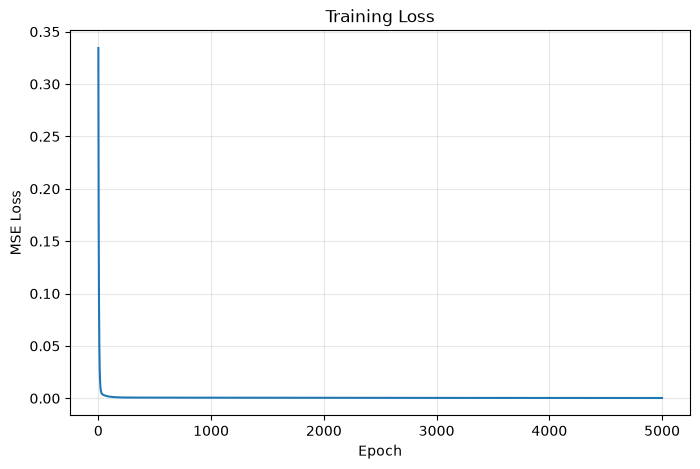

In [8]:
# 손실 곡선
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.grid(alpha=0.3)
plt.show()

### 10. 예측값을 실제 점수로 복원하기

모델의 출력은 표준화된 값입니다.  
아래 수식으로 실제 점수 단위로 되돌립니다.

$$
\hat{y}=\hat{y}_{scaled}\sigma_y+\mu_y
$$

In [9]:
# 학습 데이터 예측
model.eval()
with torch.no_grad():
    prediction_scaled = model(x_train_scaled)
    predicted_score = prediction_scaled * y_std + y_mean

# 실제값·예측값 비교
for actual, predicted in zip(y_train, predicted_score):
    print(
        f"실제: {actual.item():6.1f} | "
        f"예측: {predicted.item():6.1f}"
    )

실제:  152.0 | 예측:  151.7
실제:  185.0 | 예측:  184.6
실제:  180.0 | 예측:  180.6
실제:  196.0 | 예측:  196.0
실제:  142.0 | 예측:  142.2


### 11. 실제 점수 단위의 예측식 구하기

표준화된 모델의 매개변수를 원래 점수 단위로 변환합니다.

$$
\hat{y}=w_1x_1+w_2x_2+w_3x_3+b
$$

각 가중치는 다른 입력이 같을 때 해당 시험 점수가 1점 변하면 최종 예측값이 얼마나 변하는지를 나타냅니다.

In [10]:
# 표준화 모델의 매개변수
scaled_weight = model.linear.weight.squeeze(0)
scaled_bias = model.linear.bias.squeeze(0)

# 실제 점수 단위의 매개변수
real_weight = scaled_weight * y_std.squeeze(0) / x_std
real_bias = (
    y_mean.squeeze(0)
    + y_std.squeeze(0) * scaled_bias
    - torch.sum(real_weight * x_mean)
)

print(f"w1: {real_weight[0].item():.4f}")
print(f"w2: {real_weight[1].item():.4f}")
print(f"w3: {real_weight[2].item():.4f}")
print(f"b : {real_bias.item():.4f}")

print(
    "예측식: "
    f"y = {real_weight[0].item():.4f}x1 "
    f"{real_weight[1].item():+.4f}x2 "
    f"{real_weight[2].item():+.4f}x3 "
    f"{real_bias.item():+.4f}"
)

w1: 1.0414
w2: 0.5218
w3: 0.4376
b : 1.0868
예측식: y = 1.0414x1 +0.5218x2 +0.4376x3 +1.0868


### 12. 새로운 시험 점수 예측하기

한 명 또는 여러 명의 입력을 같은 모델로 예측할 수 있습니다.

- 한 명 입력 형상: `[1, 3]`
- 세 명 입력 형상: `[3, 3]`
- 출력 형상: `[데이터 수, 1]`

In [11]:
# 새로운 시험 점수
new_scores = torch.tensor(
    [
        [100.0, 70.0, 101.0],
        [60.0, 70.0, 110.0],
        [90.0, 100.0, 80.0],
    ],
    dtype=torch.float32,
)

# 입력 표준화
new_scores_scaled = (new_scores - x_mean) / x_std

# 최종 점수 예측·복원
model.eval()
with torch.no_grad():
    new_prediction_scaled = model(new_scores_scaled)
    new_predicted_score = new_prediction_scaled * y_std + y_mean

for scores, predicted in zip(new_scores, new_predicted_score):
    print(
        f"입력 {scores.tolist()} "
        f"→ 예상 최종 점수 {predicted.item():.1f}"
    )

입력 [100.0, 70.0, 101.0] → 예상 최종 점수 186.0
입력 [60.0, 70.0, 110.0] → 예상 최종 점수 148.2
입력 [90.0, 100.0, 80.0] → 예상 최종 점수 182.0


### 13. 평가 지표로 학습 결과 확인하기

#### MAE(엠에이이, 평균절대오차)

- 실제값과 예측값 차이의 절댓값 평균
- 단위: 점
- 평균적으로 몇 점 정도 틀리는지 확인

#### RMSE(알엠에스이, 평균제곱근오차)

- 큰 오차에 더 민감한 지표
- 단위: 점
- MAE보다 크게 증가하면 일부 예측 오차가 크다는 의미

#### $R^2$(알 스퀘어, 결정계수)

- 1에 가까울수록 실제값의 변화를 잘 설명
- 0이면 평균값으로 예측하는 수준
- 음수이면 평균값 예측보다 낮은 성능

이번 데이터는 5개뿐이므로 훈련·테스트 데이터로 나누지 않습니다.  
따라서 아래 결과는 **새로운 학생에 대한 일반화 성능이 아니라 학습 데이터 적합도**를 나타냅니다.

In [12]:
def calculate_metrics(y_true, y_pred):
    # 평균절대오차
    mae = torch.mean(torch.abs(y_true - y_pred))

    # 평균제곱근오차
    rmse = torch.sqrt(torch.mean((y_true - y_pred) ** 2))

    # 결정계수
    residual_sum = torch.sum((y_true - y_pred) ** 2)
    total_sum = torch.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - residual_sum / total_sum

    return mae, rmse, r2


mae, rmse, r2 = calculate_metrics(y_train, predicted_score)

print(f"MAE : {mae.item():.4f}점")
print(f"RMSE: {rmse.item():.4f}점")
print(f"R²  : {r2.item():.6f}")

MAE : 0.3274점
RMSE: 0.3873점
R²  : 0.999643


### 14. 실제값과 예측값 시각화하기

- 점이 대각선에 가까울수록 예측값이 실제값과 비슷함
- 데이터가 적으므로 모델 비교보다 학습 결과 확인에 활용

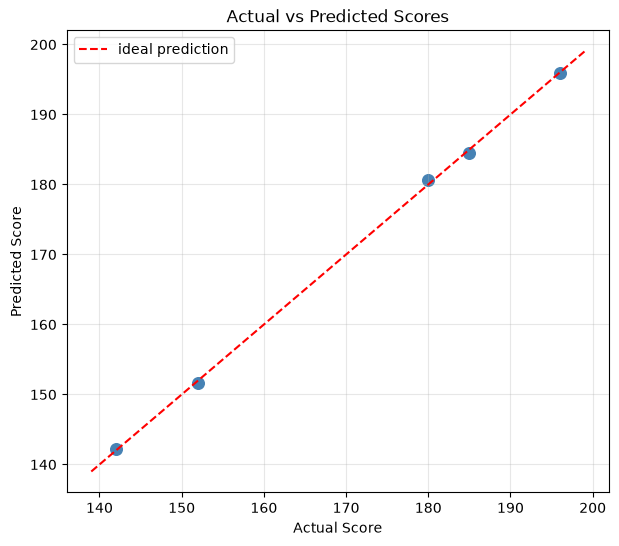

In [13]:
# 실제값·예측값
actual_values = y_train.squeeze().numpy()
predicted_values = predicted_score.squeeze().numpy()

# 비교 기준 범위
score_min = min(actual_values.min(), predicted_values.min()) - 3
score_max = max(actual_values.max(), predicted_values.max()) + 3

plt.figure(figsize=(7, 6))
plt.scatter(
    actual_values,
    predicted_values,
    color="steelblue",
    s=70,
)
plt.plot(
    [score_min, score_max],
    [score_min, score_max],
    color="red",
    linestyle="--",
    label="ideal prediction",
)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 확인 실습

Quiz 1·Quiz 2·Midterm 점수를 바꾸어 최종 점수의 변화를 확인합니다.

- 기준 입력: `[80, 80, 80]`
- 변경 입력: 각 특성을 하나씩 10점 증가
- 목적: 가중치와 입력 특성의 관계 확인

In [14]:
# 기준·변경 입력
practice_scores = torch.tensor(
    [
        [80.0, 80.0, 80.0],
        [90.0, 80.0, 80.0],
        [80.0, 90.0, 80.0],
        [80.0, 80.0, 90.0],
    ],
    dtype=torch.float32,
)

# 예측
practice_scores_scaled = (practice_scores - x_mean) / x_std

model.eval()
with torch.no_grad():
    practice_prediction_scaled = model(practice_scores_scaled)
    practice_prediction = practice_prediction_scaled * y_std + y_mean

for scores, predicted in zip(practice_scores, practice_prediction):
    print(f"{scores.tolist()} → {predicted.item():.1f}점")

[80.0, 80.0, 80.0] → 161.2점
[90.0, 80.0, 80.0] → 171.6점
[80.0, 90.0, 80.0] → 166.4점
[80.0, 80.0, 90.0] → 165.5점


## 실행 확인

아래 셀에서 오류가 없으면 `Lab 04_1`이 정상적으로 완료된 것입니다.

In [15]:
assert x_train.shape == torch.Size([5, 3])
assert y_train.shape == torch.Size([5, 1])
assert model.linear.weight.shape == torch.Size([1, 3])
assert model.linear.bias.shape == torch.Size([1])
assert matrix_prediction.shape == torch.Size([5, 1])
assert predicted_score.shape == torch.Size([5, 1])
assert new_predicted_score.shape == torch.Size([3, 1])
assert practice_prediction.shape == torch.Size([4, 1])
assert loss_history[-1] < loss_history[0]
assert mae.item() < 2.0
assert rmse.item() < 2.0
assert r2.item() > 0.99

print("Lab 04_1 실행 확인 완료")

Lab 04_1 실행 확인 완료


## 핵심 정리

- 입력 특성: Quiz 1·Quiz 2·Midterm 점수 3개
- 목표값: Final 점수 1개
- 입력 형상: `[5, 3]`
- 모델: `nn.Linear(3, 1)`
- 가중치 형상: `[1, 3]`
- 출력 형상: `[5, 1]`
- 예측식: $\hat{Y}=XW^T+b$
- 손실함수: `nn.MSELoss()`
- 최적화 도구: `SGD`
- 전처리: 입력과 목표값 표준화
- 평가 지표: MAE·RMSE·$R^2$
- 평가 범위: 학습 데이터 적합도
